# Central Limit Theorem and Law of Large Numbers

Daniel Köhn

Kiel, 27th of April 2026

**Central Limit Theorem**

In the previous random experiment, we used one dice. If we increase the number of dice per dice roll to ndice and average the rolls, the probability density distribution converges against the Normal(Gaussian) distribution. This is known as the Central Limit Theorem ...

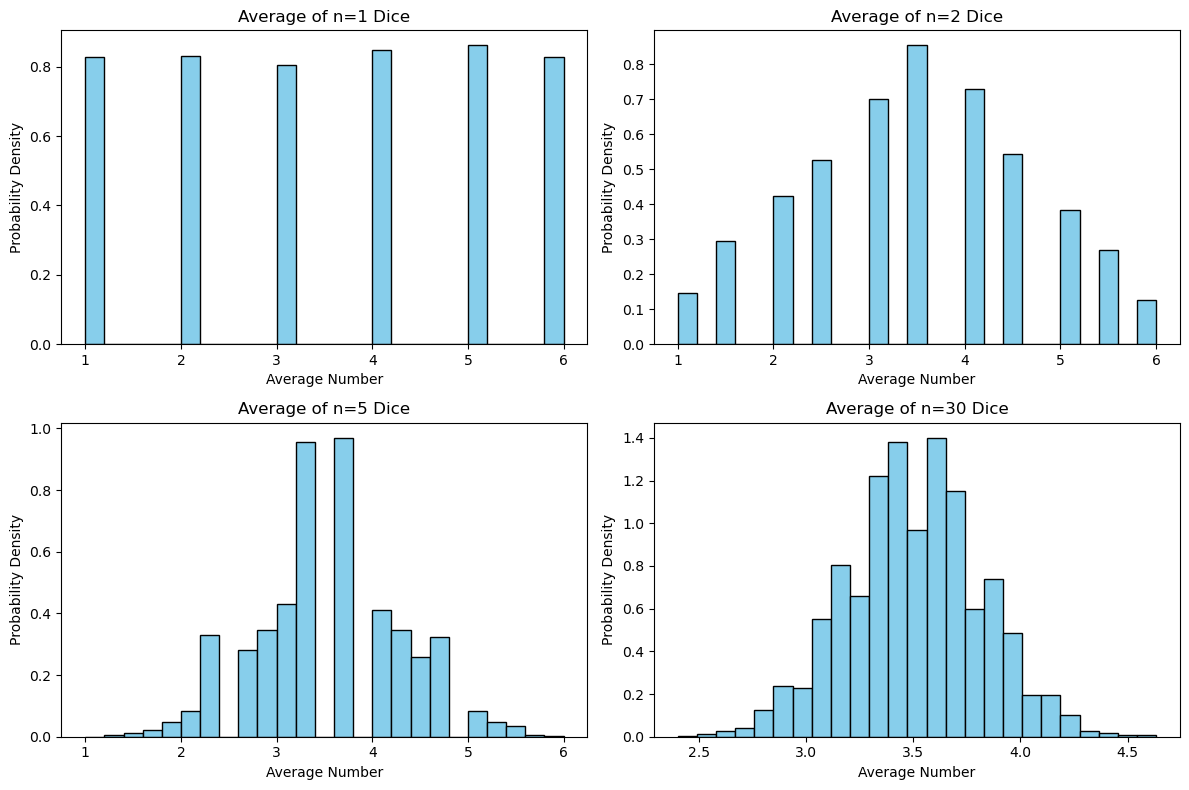

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters for Simulations
n_experimente = 10000  # How often do we want to repeat the experiment
stichproben_groessen = [1, 2, 5, 30]  # Number of Dice per roll

plt.figure(figsize=(12, 8))

for i, n in enumerate(stichproben_groessen):
    # Model the roll of 'n' dice 'n_experimente'-times
    # A fair (unloaded) dice has values between 1 and 6
    wuerfe = np.random.randint(1, 7, size=(n_experimente, n))
    
    # Compute average of 10.000 experiments
    mittelwerte = np.mean(wuerfe, axis=1)
    
    # Visualization
    plt.subplot(2, 2, i + 1)
    plt.hist(mittelwerte, bins=25, color='skyblue', edgecolor='black', density=True)
    plt.title(f'Average of n={n} Dice')
    plt.xlabel('Average Number')
    plt.ylabel('Probability Density')

plt.tight_layout()
plt.show()

Lets compare the estimated distribution of the numerical experiments with the Normal distribution ...

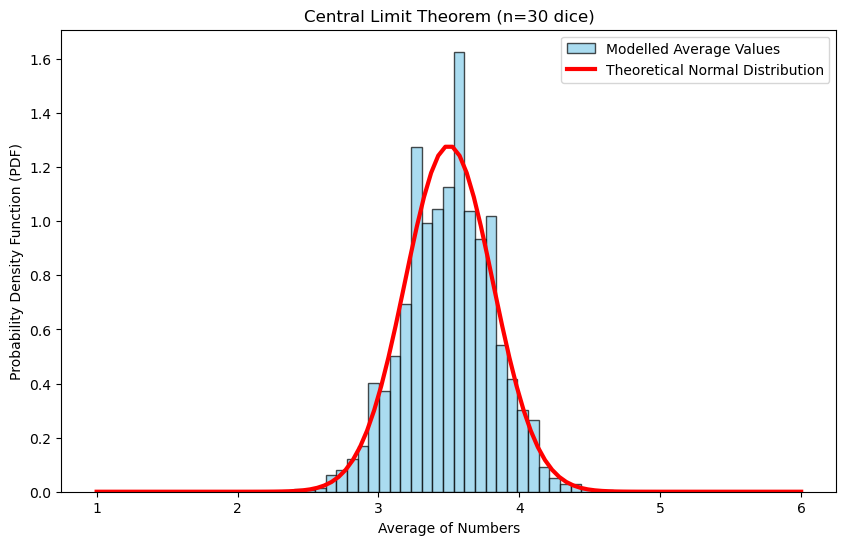

In [2]:
# Parameters
n_experimente = 10000 # number of dice rolls
n_wuerfel = 30       # number of dices per roll

# 1. Simulation of the rolls
wuerfe = np.random.randint(1, 7, size=(n_experimente, n_wuerfel))
mittelwerte = np.mean(wuerfe, axis=1)

# 2. Compute theoretical values
mu = 3.5  # expected value
# Standard Deviation of a single dice roll: ca. 1.707
sigma_einzel = np.std([1, 2, 3, 4, 5, 6]) 
sigma_mittelwert = sigma_einzel / np.sqrt(n_wuerfel)

# 3. Visualization
plt.figure(figsize=(10, 6))

# Histogram of modelled dice rolls
count, bins, ignored = plt.hist(mittelwerte, bins=30, density=True, 
                                color='skyblue', edgecolor='black', alpha=0.7, 
                                label='Modelled Average Values')

# Theoretical Gaussian Normal Distribition (PDF)
x = np.linspace(1, 6, 100)
plt.plot(x, norm.pdf(x, mu, sigma_mittelwert), color='red', lw=3, 
         label='Theoretical Normal Distribution')

plt.title(f'Central Limit Theorem (n={n_wuerfel} dice)')
plt.xlabel('Average of Numbers')
plt.ylabel('Probability Density Function (PDF)')
plt.legend()
plt.show()

**Law of Large Numbers**

We already investigate the Law of Large Numbers for one dice. In the case of an increasing number of multiple dices, the standard deviation around the expected value becomes smaller, leading to a decrease of the PDF half-width ...

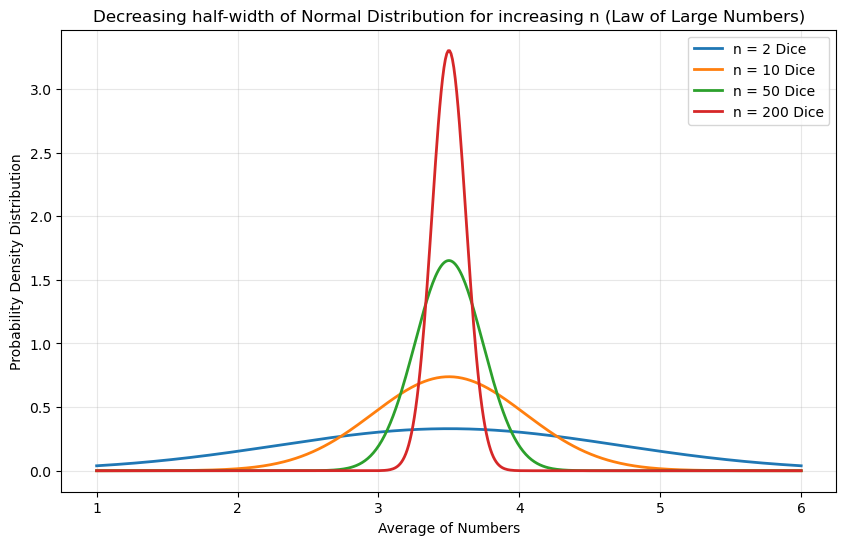

In [3]:
# Parameters
stichproben_groessen = [2, 10, 50, 200] # number of dice
x = np.linspace(1, 6, 500)
mu = 3.5    # expected value
sigma_einzel = np.std([1, 2, 3, 4, 5, 6]) # standard deviation of a single dice

plt.figure(figsize=(10, 6))

for n in stichproben_groessen:
    # Compute standard deviation for multiple dice
    sigma_n = sigma_einzel / np.sqrt(n)
    
    # Draw Normal Distribution 
    plt.plot(x, norm.pdf(x, mu, sigma_n), label=f'n = {n} Dice', lw=2)

plt.title('Decreasing half-width of Normal Distribution for increasing n (Law of Large Numbers)')
plt.xlabel('Average of Numbers')
plt.ylabel('Probability Density Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()